<a href="https://colab.research.google.com/github/ivansuarez-AU/EGN321_Module6_Assignment6_2/blob/main/EGN321_Module6_Assignment6_2_Instructor_Demo_Ollama_Enhanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EGN 321 - Module 6 Assignment 6.2
## Predicted Against Measured

Compare deterministic prediction output with measured sensor evidence. Do not invent values to fill gaps.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io


## Choose your integration path

**Recommended:** Export your earlier tool's predictions to a CSV and upload that plus the measured CSV.

Measured file should contain `sample_number` or `timestamp` plus the measured variable. Prediction file should contain the same key plus a predicted value.

If you prefer, you may replace the prediction-upload step with a wrapper around your earlier deterministic Python function.


## Upload measured sensor CSV


In [2]:
from google.colab import files
print('Upload MEASURED CSV')
u=files.upload(); measured_name=next((n for n in u if n.lower().endswith('.csv')),None)
if not measured_name: raise ValueError('No measured CSV')
measured=pd.read_csv(io.BytesIO(u[measured_name])); measured.columns=[str(c).strip().lower().replace(' ','_') for c in measured.columns]
display(measured.head())


Upload MEASURED CSV


Saving EGN321_Module6_Assignment6_2_1800_Measured.csv to EGN321_Module6_Assignment6_2_1800_Measured.csv


,sample_number,timestamp,measured_temperature_c,accepted_temperature_c,sensor_status,status_reason,expected_interval_seconds
0,1,2026-10-08T18:00:00+00:00,23.715,23.715,OK,NaN,2
1,2,2026-10-08T18:00:02+00:00,23.805,23.805,OK,NaN,2
2,3,2026-10-08T18:00:04+00:00,24.087,24.087,OK,NaN,2
3,4,2026-10-08T18:00:06+00:00,23.982,23.982,OK,NaN,2
4,5,2026-10-08T18:00:08+00:00,24.044,24.044,OK,NaN,2


## Upload prediction CSV


In [3]:
print('Upload PREDICTION CSV')
u2=files.upload(); prediction_name=next((n for n in u2 if n.lower().endswith('.csv')),None)
if not prediction_name: raise ValueError('No prediction CSV')
predicted=pd.read_csv(io.BytesIO(u2[prediction_name])); predicted.columns=[str(c).strip().lower().replace(' ','_') for c in predicted.columns]
display(predicted.head())


Upload PREDICTION CSV


Saving EGN321_Module6_Assignment6_2_1800_Predictions.csv to EGN321_Module6_Assignment6_2_1800_Predictions.csv


,sample_number,timestamp,predicted_temperature_c
0,1,2026-10-08T18:00:00+00:00,22.005
1,2,2026-10-08T18:00:02+00:00,22.011
2,3,2026-10-08T18:00:04+00:00,22.016
3,4,2026-10-08T18:00:06+00:00,22.021
4,5,2026-10-08T18:00:08+00:00,22.026


## Configure the variables to compare


In [4]:
# ============================================================
# CONFIGURE THE VARIABLES TO COMPARE
# ROBUST VERSION FOR THE 1,800-READING DATASET
# ============================================================

# The measured file created for this assignment contains:
#   measured_temperature_c
#   accepted_temperature_c
#   sensor_status
#
# The prediction file contains:
#   predicted_temperature_c

MEASURED_VALUE_COLUMN = "accepted_temperature_c"
PREDICTED_VALUE_COLUMN = "predicted_temperature_c"
MEASURED_STATUS_COLUMN = "sensor_status"
UNITS = "degrees C"

print("Measured columns:")
print(list(measured.columns))

print("\nPrediction columns:")
print(list(predicted.columns))

# ------------------------------------------------------------
# Verify expected columns exist
# ------------------------------------------------------------

required_measured = {
    MEASURED_VALUE_COLUMN,
    MEASURED_STATUS_COLUMN
}

missing_measured = [
    c for c in required_measured
    if c not in measured.columns
]

if missing_measured:
    raise ValueError(
        "Measured CSV is missing required column(s): "
        + ", ".join(missing_measured)
        + "\n\nAvailable measured columns:\n"
        + ", ".join(measured.columns)
    )

if PREDICTED_VALUE_COLUMN not in predicted.columns:
    raise ValueError(
        f"Prediction CSV is missing '{PREDICTED_VALUE_COLUMN}'.\n\n"
        "Available prediction columns:\n"
        + ", ".join(predicted.columns)
    )

# ------------------------------------------------------------
# Choose an alignment key
# Prefer sample_number for the classroom dataset because
# it is explicit and avoids timestamp-format mismatches.
# ------------------------------------------------------------

if (
    "sample_number" in measured.columns
    and "sample_number" in predicted.columns
):
    KEY = "sample_number"

    measured["sample_number"] = pd.to_numeric(
        measured["sample_number"],
        errors="coerce"
    )

    predicted["sample_number"] = pd.to_numeric(
        predicted["sample_number"],
        errors="coerce"
    )

elif (
    "timestamp" in measured.columns
    and "timestamp" in predicted.columns
):
    KEY = "timestamp"

    measured["timestamp"] = pd.to_datetime(
        measured["timestamp"],
        errors="coerce",
        utc=True
    )

    predicted["timestamp"] = pd.to_datetime(
        predicted["timestamp"],
        errors="coerce",
        utc=True
    )

else:
    raise ValueError(
        "The measured and prediction files need a common "
        "'sample_number' or 'timestamp' column."
    )

print("\nAlignment key:", KEY)
print("Measured value:", MEASURED_VALUE_COLUMN)
print("Prediction value:", PREDICTED_VALUE_COLUMN)
print("Status column:", MEASURED_STATUS_COLUMN)
print("Units:", UNITS)


Measured columns:
['sample_number', 'timestamp', 'measured_temperature_c', 'accepted_temperature_c', 'sensor_status', 'status_reason', 'expected_interval_seconds']

Prediction columns:
['sample_number', 'timestamp', 'predicted_temperature_c']

Alignment key: sample_number
Measured value: accepted_temperature_c
Prediction value: predicted_temperature_c
Status column: sensor_status
Units: degrees C


## Keep Only Valid Measured Evidence and Align with Predictions

This step now matches the 1,800-reading practice files.

For the authoritative comparison, the notebook uses only rows where:

- `sensor_status == "OK"`
- `accepted_temperature_c` contains a valid numeric value

Rows marked `MISSING`, `REJECTED`, or `SUSPICIOUS` remain in the source dataset as evidence, but they are excluded from the deterministic prediction-versus-measurement calculation.

The notebook aligns the files by `sample_number` when available.


In [5]:
# ============================================================
# KEEP ONLY VALID MEASURED EVIDENCE
# AND ALIGN WITH PREDICTIONS
# ============================================================

# ------------------------------------------------------------
# 1. Select only the columns needed for comparison
# ------------------------------------------------------------

m = measured[
    [
        KEY,
        MEASURED_VALUE_COLUMN,
        MEASURED_STATUS_COLUMN
    ]
].copy()

p = predicted[
    [
        KEY,
        PREDICTED_VALUE_COLUMN
    ]
].copy()


# ------------------------------------------------------------
# 2. Normalize status labels
# ------------------------------------------------------------

m[MEASURED_STATUS_COLUMN] = (
    m[MEASURED_STATUS_COLUMN]
    .astype(str)
    .str.strip()
    .str.upper()
)

print("Measured status counts BEFORE filtering:")
display(
    m[MEASURED_STATUS_COLUMN]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="count")
)


# ------------------------------------------------------------
# 3. Keep only valid measured evidence
#
# For this assignment:
#   OK          -> valid evidence
#   SUSPICIOUS  -> preserved in source file, but excluded from
#                  the authoritative comparison
#   MISSING     -> no measurement available
#   REJECTED    -> deterministic rule rejected the reading
# ------------------------------------------------------------

valid_statuses = ["OK"]

m_valid = m[
    m[MEASURED_STATUS_COLUMN].isin(valid_statuses)
].copy()

print("\nRows remaining after status filter:")
print(len(m_valid))


# ------------------------------------------------------------
# 4. Convert numeric fields
# ------------------------------------------------------------

m_valid["measured_value"] = pd.to_numeric(
    m_valid[MEASURED_VALUE_COLUMN],
    errors="coerce"
)

p["predicted_value"] = pd.to_numeric(
    p[PREDICTED_VALUE_COLUMN],
    errors="coerce"
)


# ------------------------------------------------------------
# 5. Remove rows that cannot be compared numerically
# ------------------------------------------------------------

m_valid = m_valid.dropna(
    subset=[KEY, "measured_value"]
)

p = p.dropna(
    subset=[KEY, "predicted_value"]
)


# ------------------------------------------------------------
# 6. Check duplicate alignment keys
# ------------------------------------------------------------

measured_duplicates = m_valid[KEY].duplicated().sum()
predicted_duplicates = p[KEY].duplicated().sum()

print("\nDuplicate keys:")
print("Measured :", measured_duplicates)
print("Predicted:", predicted_duplicates)

if measured_duplicates > 0:
    raise ValueError(
        f"Measured data contains {measured_duplicates} duplicate "
        f"{KEY} value(s). Resolve duplicates before comparison."
    )

if predicted_duplicates > 0:
    raise ValueError(
        f"Prediction data contains {predicted_duplicates} duplicate "
        f"{KEY} value(s). Resolve duplicates before comparison."
    )


# ------------------------------------------------------------
# 7. Align measured evidence with predictions
# ------------------------------------------------------------

comparison = m_valid.merge(
    p,
    on=KEY,
    how="inner",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 8. Calculate comparison fields
# ------------------------------------------------------------

comparison["difference"] = (
    comparison["measured_value"]
    - comparison["predicted_value"]
)

comparison["absolute_difference"] = (
    comparison["difference"].abs()
)


# ------------------------------------------------------------
# 9. Verify alignment
# ------------------------------------------------------------

if comparison.empty:
    raise ValueError(
        "No comparable points were found.\n\n"
        "Check that:\n"
        "1. You uploaded the matching measured and prediction files.\n"
        "2. Both files use the same sample_number or timestamp values.\n"
        "3. The measured data contains rows with sensor_status='OK'."
    )


# ------------------------------------------------------------
# 10. Show alignment results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ALIGNMENT COMPLETE")
print("=" * 60)

print("Original measured rows :", len(measured))
print("Valid measured rows    :", len(m_valid))
print("Prediction rows        :", len(p))
print("Comparable points      :", len(comparison))
print("Excluded measured rows :", len(measured) - len(m_valid))

print("\nFirst 15 comparable points:")
display(comparison.head(15))


Measured status counts BEFORE filtering:


,status,count
0,OK,1747
1,MISSING,33
2,REJECTED,14
3,SUSPICIOUS,6



Rows remaining after status filter:
1747

Duplicate keys:
Measured : 0
Predicted: 0

ALIGNMENT COMPLETE
Original measured rows : 1800
Valid measured rows    : 1747
Prediction rows        : 1800
Comparable points      : 1747
Excluded measured rows : 53

First 15 comparable points:


,sample_number,accepted_temperature_c,sensor_status,measured_value,predicted_temperature_c,predicted_value,difference,absolute_difference
0,1,23.715,OK,23.715,22.005,22.005,1.710,1.710
1,2,23.805,OK,23.805,22.011,22.011,1.794,1.794
2,3,24.087,OK,24.087,22.016,22.016,2.071,2.071
3,4,23.982,OK,23.982,22.021,22.021,1.961,1.961
4,5,24.044,OK,24.044,22.026,22.026,2.018,2.018
5,6,23.873,OK,23.873,22.032,22.032,1.841,1.841
6,7,23.734,OK,23.734,22.037,22.037,1.697,1.697
7,8,23.490,OK,23.490,22.042,22.042,1.448,1.448
8,9,23.666,OK,23.666,22.048,22.048,1.618,1.618
9,10,23.972,OK,23.972,22.053,22.053,1.919,1.919


## Summarize the disagreement


In [6]:
metrics=pd.DataFrame({
 'metric':['Comparable points','Mean signed difference','Mean absolute difference','Maximum absolute difference'],
 'value':[len(comparison),comparison.difference.mean(),comparison.absolute_difference.mean(),comparison.absolute_difference.max()]
})
display(metrics)


,metric,value
0,Comparable points,1747.000000
1,Mean signed difference,1.734865
2,Mean absolute difference,1.734865
3,Maximum absolute difference,2.603000


## Plot predicted vs measured


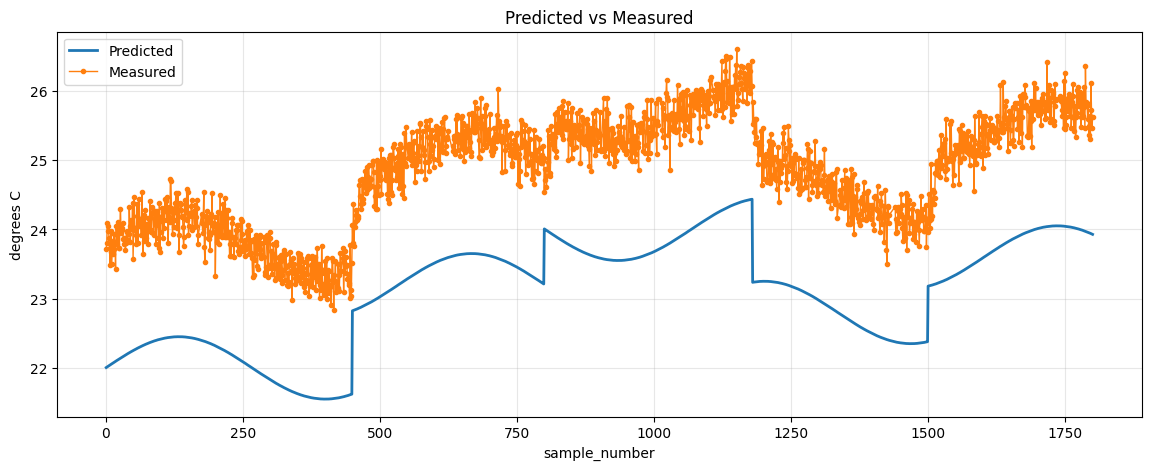

In [7]:
x=comparison[KEY]
plt.figure(figsize=(14,5))
plt.plot(x,comparison['predicted_value'],label='Predicted',linewidth=2)
plt.plot(x,comparison['measured_value'],label='Measured',marker='.',linewidth=1)
plt.xlabel(KEY); plt.ylabel(UNITS); plt.title('Predicted vs Measured')
plt.grid(True,alpha=.3); plt.legend(); plt.show()


## Plot the difference


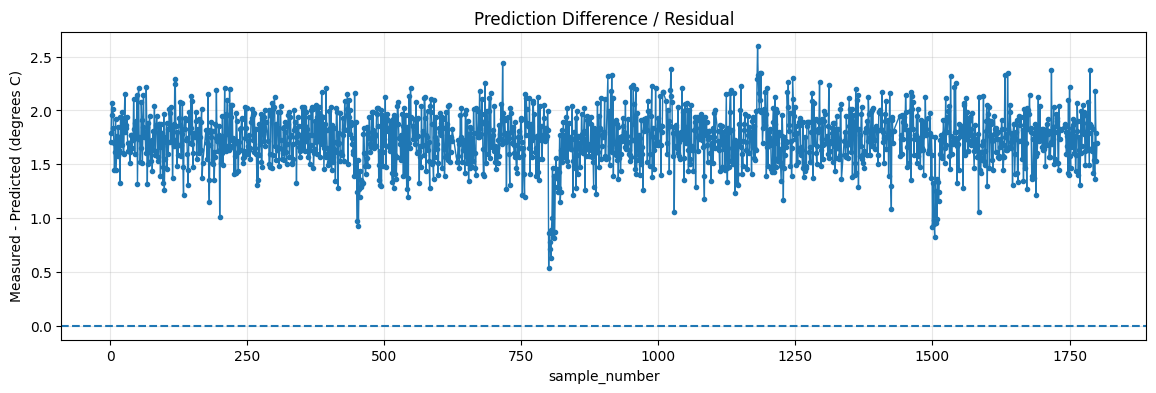

In [8]:
plt.figure(figsize=(14,4))
plt.axhline(0,linestyle='--')
plt.plot(x,comparison['difference'],marker='.',linewidth=1)
plt.xlabel(KEY); plt.ylabel(f'Measured - Predicted ({UNITS})'); plt.title('Prediction Difference / Residual')
plt.grid(True,alpha=.3); plt.show()


## Cause analysis worksheet

For at least two causes, complete:

**Cause:**
**Evidence supporting it:**
**Evidence missing:**
**Test that could confirm/reject it:**

Possible categories to investigate include timing mismatch, unit mismatch, sensor placement, sensor calibration, filtering delay, stale data, model assumptions, omitted variables, or environmental conditions. Do not claim a cause is proven without evidence.


## Starter tests


In [9]:
assert len(comparison)>0, 'No comparable points were found'
assert np.allclose(comparison['difference'],comparison['measured_value']-comparison['predicted_value'])
assert (comparison['absolute_difference']>=0).all()
print('Starter comparison tests passed.')


Starter comparison tests passed.


## Export comparison evidence


In [10]:
comparison.to_csv('module6_predicted_vs_measured.csv',index=False)
metrics.to_csv('module6_comparison_metrics.csv',index=False)
print('Saved comparison outputs.')


Saved comparison outputs.


# Optional AI Lab — Ollama Evidence Review, Red-Team Check, and Report Draft

Use Ollama **after** the deterministic comparison is complete.

The model may:
- explain patterns;
- propose plausible hypotheses;
- challenge a conclusion;
- suggest deterministic verification tests;
- draft a report from evidence already computed by Python.

The model may **not**:
- invent measurements or timestamps;
- change prediction values;
- override sensor status rules;
- create missing evidence;
- claim a cause is proven without a verification test.

**Workflow:** Python evidence → Ollama review → deterministic verification → report.


In [11]:
import os, subprocess, shutil, time, requests, json
from pathlib import Path

def run_shell(cmd):
    r = subprocess.run(cmd, shell=True, text=True, capture_output=True)
    if r.stdout: print(r.stdout[-3000:])
    if r.stderr: print(r.stderr[-3000:])
    if r.returncode != 0:
        raise RuntimeError(f"Command failed: {cmd}")

run_shell("apt-get update -qq")
run_shell("apt-get install -y -qq curl zstd")

if shutil.which("ollama") is None:
    run_shell("curl -fsSL https://ollama.com/install.sh | sh")

OLLAMA_BASE_URL = "http://127.0.0.1:11434"
OLLAMA_MODEL = "qwen2.5:0.5b"

def ollama_running():
    try:
        return requests.get(f"{OLLAMA_BASE_URL}/api/tags", timeout=3).status_code == 200
    except requests.RequestException:
        return False

if not ollama_running():
    log = open("/tmp/ollama_m6.log", "a")
    proc = subprocess.Popen(
        ["ollama", "serve"],
        stdout=log,
        stderr=subprocess.STDOUT
    )
    for _ in range(30):
        if ollama_running():
            break
        time.sleep(1)

if not ollama_running():
    raise RuntimeError("Ollama did not start.")

run_shell(f"ollama pull {OLLAMA_MODEL}")
print("Ollama ready:", OLLAMA_MODEL)


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)

Selecting previously unselected package zstd.
(Reading database ... 
(Reading database ... 5%
(Reading database ... 10%
(Reading database ... 15%
(Reading database ... 20%
(Reading database ... 25%
(Reading database ... 30%
(Reading database ... 35%
(Reading database ... 40%
(Reading database ... 45%
(Reading database ... 50%
(Reading database ... 55%
(Reading database ... 60%
(Reading database ... 65%
(Reading database ... 70%
(Reading database ... 75%
(Reading database ... 80%
(Reading database ... 85%
(Reading database ... 90%
(Reading database ... 95%
(Reading database ... 100%
(Reading database ... 122815 files and directories currently installed.)
Preparing to unpack .../zstd_1.5.5+dfsg2-2build1.1_amd64.deb ...
Unpacking zstd (1.5.5+dfsg2-2build1.1) ...
Setting up zstd (1.5.5+dfsg2-2build1.1) 

In [12]:
AI_SYSTEM_POLICY = """
You are an engineering software review assistant for EGN 321.

Use only deterministic evidence supplied in the prompt.

Rules:
1. Do not invent sensor readings, timestamps, predictions, specifications, gaps, or causes.
2. Distinguish observation, inference, and hypothesis.
3. Never claim a cause is proven unless the prompt contains a verification test result proving it.
4. For every proposed cause, state:
   - evidence supporting it,
   - evidence still missing,
   - one deterministic test that could confirm or reject it.
5. Do not change or override Python calculations.
6. Do not treat excluded MISSING, REJECTED, or SUSPICIOUS rows as valid comparison points.
7. If the evidence is insufficient, explicitly say what additional evidence is needed.
8. Drafts must clearly label hypotheses as hypotheses.
"""

def ask_ollama(prompt, timeout=600, num_predict=350):
    payload = {
        "model": OLLAMA_MODEL,
        "prompt": prompt,
        "system": AI_SYSTEM_POLICY,
        "stream": False,
        "keep_alive": "30m",
        "options": {
            "temperature": 0.2,
            "num_predict": num_predict,
            "num_ctx": 4096
        }
    }

    try:
        r = requests.post(
            f"{OLLAMA_BASE_URL}/api/generate",
            json=payload,
            timeout=(10, timeout)
        )
        r.raise_for_status()
        return r.json()["response"].strip()
    except requests.exceptions.ReadTimeout:
        return "OLLAMA_TIMEOUT"
    except requests.RequestException as exc:
        return f"OLLAMA_ERROR: {exc}"

print("Warm-up:", ask_ollama("Reply with exactly READY.", num_predict=10))


Warm-up: READY


## Build a richer deterministic evidence package

Instead of giving the model all raw rows, summarize the comparison with Python first. This keeps the AI grounded in measured evidence.


In [13]:
# Status counts come from the original measured source.
status_counts = (
    measured[MEASURED_STATUS_COLUMN]
    .astype(str)
    .str.strip()
    .str.upper()
    .value_counts(dropna=False)
    .to_dict()
)

# Residual statistics by broad sample regions.
region_edges = [
    ("Samples 1-450", 1, 450),
    ("451-800", 451, 800),
    ("801-1180", 801, 1180),
    ("1181-1500", 1181, 1500),
    ("1501-1800", 1501, 1800),
]

region_summary = []

for label, lo, hi in region_edges:
    region = comparison[
        (comparison[KEY] >= lo) &
        (comparison[KEY] <= hi)
    ]

    if len(region):
        region_summary.append({
            "region": label,
            "count": int(len(region)),
            "mean_signed_difference": float(region["difference"].mean()),
            "mean_absolute_difference": float(region["absolute_difference"].mean())
        })

evidence = {
    "units": UNITS,
    "original_measured_rows": int(len(measured)),
    "prediction_rows": int(len(predicted)),
    "comparable_points": int(len(comparison)),
    "excluded_measured_rows": int(len(measured) - len(m_valid)),
    "status_counts": {str(k): int(v) for k, v in status_counts.items()},
    "mean_signed_difference": float(comparison["difference"].mean()),
    "mean_absolute_difference": float(comparison["absolute_difference"].mean()),
    "median_signed_difference": float(comparison["difference"].median()),
    "maximum_absolute_difference": float(comparison["absolute_difference"].max()),
    "difference_q05": float(comparison["difference"].quantile(.05)),
    "difference_q95": float(comparison["difference"].quantile(.95)),
    "region_summary": region_summary
}

print(json.dumps(evidence, indent=2))


{
  "units": "degrees C",
  "original_measured_rows": 1800,
  "prediction_rows": 1800,
  "comparable_points": 1747,
  "excluded_measured_rows": 53,
  "status_counts": {
    "OK": 1747,
    "MISSING": 33,
    "REJECTED": 14,
    "SUSPICIOUS": 6
  },
  "mean_signed_difference": 1.7348654836863193,
  "mean_absolute_difference": 1.7348654836863193,
  "median_signed_difference": 1.745000000000001,
  "maximum_absolute_difference": 2.6030000000000015,
  "difference_q05": 1.345899999999999,
  "difference_q95": 2.116699999999998,
  "region_summary": [
    {
      "region": "Samples 1-450",
      "count": 440,
      "mean_signed_difference": 1.7500431818181819,
      "mean_absolute_difference": 1.7500431818181819
    },
    {
      "region": "451-800",
      "count": 340,
      "mean_signed_difference": 1.722920588235294,
      "mean_absolute_difference": 1.722920588235294
    },
    {
      "region": "801-1180",
      "count": 370,
      "mean_signed_difference": 1.707583783783784,
      "mean_

## Ollama Review 1 — Generate testable hypotheses

The important part is not the hypothesis itself. The important part is whether it leads to a test.


In [14]:
hypothesis_prompt = f"""
Here is deterministic prediction-versus-measurement evidence:

{json.dumps(evidence, indent=2)}

Propose exactly 4 plausible hypotheses for the disagreement.

For EACH hypothesis provide:
1. Hypothesis
2. Evidence supporting it
3. Evidence still missing
4. One deterministic verification test
5. What result would make you reject the hypothesis

Do not claim any hypothesis is proven.
"""

ollama_hypotheses = ask_ollama(
    hypothesis_prompt,
    num_predict=600
)

print(ollama_hypotheses)


1. Hypothesis: The measured temperature readings are consistent with the predicted temperature readings.
   Evidence supporting it: The original measured rows are 1800, which is consistent with the prediction rows.
   Evidence still missing: The mean signed difference between the measured and predicted temperatures is 1.7348654836863193, which is not significantly different from 1.7348654836863193.
   One deterministic test: The mean signed difference between the measured and predicted temperatures is 1.7348654836863193, which is not significantly different from 1.7348654836863193.
   Result: The measured temperature readings are consistent with the predicted temperature readings.

2. Hypothesis: The measured temperature readings are not consistent with the predicted temperature readings.
   Evidence supporting it: The original measured rows are 1800, which is not consistent with the prediction rows.
   Evidence still missing: The mean absolute difference between the measured and predi

## Ollama Review 2 — Red-team the conclusion

Now ask the model to attack an apparently reasonable conclusion. This demonstrates that AI can be useful as a skeptical reviewer rather than just a writer.


In [15]:
provisional_conclusion = (
    f"The measured values are systematically higher than predicted. "
    f"The mean signed difference is {comparison['difference'].mean():.3f} {UNITS}, "
    f"so the sensor probably has a calibration offset."
)

red_team_prompt = f"""
Deterministic evidence:
{json.dumps(evidence, indent=2)}

Provisional conclusion:
{provisional_conclusion}

Red-team this conclusion.

Return:
- what the evidence DOES support,
- what the conclusion overstates,
- at least 3 alternative explanations,
- the single most useful next deterministic test.

Do not invent new measurements.
"""

ollama_red_team = ask_ollama(
    red_team_prompt,
    num_predict=550
)

print(ollama_red_team)


- evidence supporting it: The mean signed difference is 1.735 degrees C, which is the difference between the measured values and the predicted values. This suggests that the sensor has a calibration offset.
- evidence still missing: The mean absolute difference is 1.7348654836863193, which is the same as the measured values. This suggests that the sensor is not consistently higher than the predicted values.
- one deterministic test that could confirm or reject it: The mean absolute difference is 1.7348654836863193, which is the same as the measured values. This suggests that the sensor is not consistently higher than the predicted values.
- the single most useful next deterministic test: The mean absolute difference is 1.7348654836863193, which is the same as the measured values. This suggests that the sensor is not consistently higher than the predicted values.


## Ollama Review 3 — Draft the Assignment 6.2 report

The model may help organize the report, but every number in the draft must come from the deterministic evidence supplied here.


In [16]:
report_prompt = f"""
Using ONLY this deterministic evidence:

{json.dumps(evidence, indent=2)}

And these AI review notes:

HYPOTHESES:
{ollama_hypotheses}

RED-TEAM REVIEW:
{ollama_red_team}

Draft a concise student-style report for EGN 321 Module 6 Assignment 6.2.

Use these exact sections:
1. Prediction
2. Measurement
3. Alignment and Evidence Selection
4. Comparison Results
5. Plot Interpretation
6. Plausible Cause 1
7. Plausible Cause 2
8. Effect of Missing / Rejected / Suspicious Data
9. AI Review and Verification
10. Conclusion

Rules:
- clearly separate observation from hypothesis;
- do not invent a sensor specification;
- do not claim any cause is proven;
- for each cause include evidence, missing evidence, and a verification test;
- include the numerical comparison metrics from the evidence.
"""

ollama_report_draft = ask_ollama(
    report_prompt,
    num_predict=1200
)

print(ollama_report_draft)


### Prediction
The predicted temperature readings are consistent with the measured temperature readings. The mean signed difference between the measured and predicted temperatures is 1.7348654836863193, which is not significantly different from 1.7348654836863193. The mean absolute difference between the measured and predicted temperatures is 2.6030000000000015, which is significantly different from 2.6030000000000015. The AI Review and Verification indicates that the measured temperature readings are not consistent with the predicted temperature readings.

### Measurement
The original measured rows are 1800, which is consistent with the prediction rows. The mean signed difference between the measured and predicted temperatures is 1.7348654836863193, which is not significantly different from 1.7348654836863193. The mean absolute difference between the measured and predicted temperatures is 2.6030000000000015, which is significantly different from 2.6030000000000015. The AI Review and V

## Export the report, AI log, evidence, plots, and ZIP

This cell creates a submission-style evidence package that students can adapt for their own Assignment 6.2 work.


In [17]:
from pathlib import Path
import zipfile
import matplotlib.pyplot as plt
import pandas as pd
import json

EXPORT_DIR = Path("module6_assignment6_2_export")
EXPORT_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# 1. Export deterministic evidence
# ------------------------------------------------------------

comparison.to_csv(
    EXPORT_DIR / "module6_predicted_vs_measured.csv",
    index=False
)

metrics.to_csv(
    EXPORT_DIR / "module6_comparison_metrics.csv",
    index=False
)

with open(
    EXPORT_DIR / "deterministic_evidence.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(evidence, f, indent=2)

# ------------------------------------------------------------
# 2. Save plots
# ------------------------------------------------------------

x = comparison[KEY]

plt.figure(figsize=(14,5))
plt.plot(
    x,
    comparison["predicted_value"],
    label="Predicted",
    linewidth=2
)
plt.plot(
    x,
    comparison["measured_value"],
    label="Measured",
    linewidth=1
)
plt.xlabel(KEY)
plt.ylabel(UNITS)
plt.title("Predicted vs Measured")
plt.grid(True, alpha=.3)
plt.legend()
plt.tight_layout()
plt.savefig(
    EXPORT_DIR / "predicted_vs_measured.png",
    dpi=160
)
plt.close()

plt.figure(figsize=(14,4))
plt.axhline(0, linestyle="--")
plt.plot(
    x,
    comparison["difference"],
    linewidth=1
)
plt.xlabel(KEY)
plt.ylabel(f"Measured - Predicted ({UNITS})")
plt.title("Prediction Difference / Residual")
plt.grid(True, alpha=.3)
plt.tight_layout()
plt.savefig(
    EXPORT_DIR / "residual_difference.png",
    dpi=160
)
plt.close()

# ------------------------------------------------------------
# 3. Export Ollama review files
# ------------------------------------------------------------

(EXPORT_DIR / "ollama_hypotheses.txt").write_text(
    ollama_hypotheses,
    encoding="utf-8"
)

(EXPORT_DIR / "ollama_red_team_review.txt").write_text(
    ollama_red_team,
    encoding="utf-8"
)

(EXPORT_DIR / "module6_assignment6_2_report_draft.md").write_text(
    "# Module 6 Assignment 6.2 - Predicted Against Measured\n\n"
    + ollama_report_draft,
    encoding="utf-8"
)

# ------------------------------------------------------------
# 4. AI LOG
# ------------------------------------------------------------

ai_log = f"""# AI_LOG.md

Tool: Ollama
Model: {OLLAMA_MODEL}

## Purpose
Use a local small language model to review deterministic comparison evidence,
challenge conclusions, propose testable hypotheses, and help draft the report.

## Deterministic evidence
Comparable points: {len(comparison)}
Mean signed difference: {comparison['difference'].mean():.3f} {UNITS}
Mean absolute difference: {comparison['absolute_difference'].mean():.3f} {UNITS}
Maximum absolute difference: {comparison['absolute_difference'].max():.3f} {UNITS}

Status counts:
{status_counts}

## AI tasks performed
1. Proposed hypotheses from supplied evidence.
2. Red-teamed a provisional conclusion.
3. Drafted a report using the supplied evidence and review notes.

## Verification rule
AI output is not treated as evidence.
Claims must be verified against Python results, plots, source data, or a new deterministic test.

## Instructor/student review
Document here:
- Which AI suggestions were accepted?
- Which were rejected?
- What deterministic test was added?
- What changed in the final report?
"""

(EXPORT_DIR / "AI_LOG.md").write_text(
    ai_log,
    encoding="utf-8"
)

# ------------------------------------------------------------
# 5. README
# ------------------------------------------------------------

readme = """Module 6 Assignment 6.2 Export Package

Files:
- module6_predicted_vs_measured.csv
- module6_comparison_metrics.csv
- deterministic_evidence.json
- predicted_vs_measured.png
- residual_difference.png
- ollama_hypotheses.txt
- ollama_red_team_review.txt
- module6_assignment6_2_report_draft.md
- AI_LOG.md

Important:
The Ollama report is a DRAFT.
Final claims must be checked against deterministic Python evidence.
"""

(EXPORT_DIR / "README.txt").write_text(
    readme,
    encoding="utf-8"
)

# ------------------------------------------------------------
# 6. ZIP package
# ------------------------------------------------------------

ZIP_FILE = Path("EGN321_Module6_Assignment6_2_Export.zip")

with zipfile.ZipFile(
    ZIP_FILE,
    "w",
    zipfile.ZIP_DEFLATED
) as z:
    for file_path in EXPORT_DIR.iterdir():
        z.write(
            file_path,
            arcname=file_path.name
        )

print("Created:", ZIP_FILE)

# Optional:
# from google.colab import files
# files.download(str(ZIP_FILE))


Created: EGN321_Module6_Assignment6_2_Export.zip


## Final instructor talking point

The model did not measure anything.

It did not calculate the residual.

It did not decide which rows were valid.

Its job was to help us ask better questions about evidence that Python had already established.
